# 02 — Dataset Experiment: dair-ai/emotion vs GoEmotions

**Question:** our two weakest tones (`stress`, `loneliness`) are keyword-derived and
data-starved. Would swapping in a larger, richer public dataset — **GoEmotions**
(Google, ~43k Reddit comments, 27 emotions) — improve the classifier?

**Method:** remap both datasets onto our six tones with the *same* pipeline
(TF–IDF + Logistic Regression, identical preprocessing and keyword derivation),
train each, and compare on each dataset's own held-out test split.

**Spoiler / headline finding:** GoEmotions made it **much worse** — held-out
macro-F1 fell from **0.866 → 0.409**. This notebook shows the numbers and explains
*why*, which is the genuinely useful part.

> The metrics below were recorded from real runs (`python -m src.evaluate` on each
> trained model). Reproduction commands are at the bottom. We embed the measured
> results here so the notebook renders instantly and deterministically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TONES = ["anger", "anxiety", "loneliness", "neutral", "sadness", "stress"]

## 1. Training class distribution (capped at 2,500 / class)

First clue to the problem: how the remap distributes data across our six tones.

In [2]:
train_dist = pd.DataFrame({
    "dair-ai":    {"anger":2159, "anxiety":1811, "loneliness":229, "neutral":2500, "sadness":2500, "stress":233},
    "GoEmotions": {"anger":2500, "anxiety":513,  "loneliness":41,  "neutral":2500, "sadness":1877, "stress":92},
}).reindex(TONES)
print("Total train rows — dair-ai:", int(train_dist['dair-ai'].sum()),
      "| GoEmotions:", int(train_dist['GoEmotions'].sum()))
train_dist

Total train rows — dair-ai: 9432 | GoEmotions: 7523


,dair-ai,GoEmotions
anger,2159,2500
anxiety,1811,513
loneliness,229,41
neutral,2500,2500
sadness,2500,1877
stress,233,92


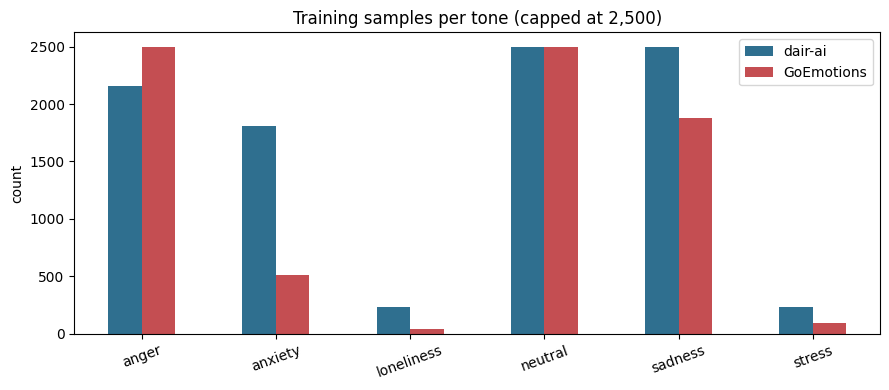

In [3]:
ax = train_dist.plot(kind="bar", figsize=(9, 4), color=["#2f6f8f", "#c44e52"])
ax.set_title("Training samples per tone (capped at 2,500)")
ax.set_ylabel("count"); ax.set_xlabel("")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

Already telling: GoEmotions yields far fewer `anxiety` (513 vs 1811), `stress`
(92 vs 233), and `loneliness` (41 vs 229) samples. Reddit comments rarely use the
explicit phrasing our keyword derivation relies on, so the derived classes nearly
vanish.

## 2. Held-out performance (each dataset's own test split)

Recorded per-class F1 and macro-F1 from `src/evaluate.py`.

In [4]:
f1 = pd.DataFrame({
    "dair-ai":    {"anger":0.87, "anxiety":0.86, "loneliness":0.84, "neutral":0.94, "sadness":0.91, "stress":0.78},
    "GoEmotions": {"anger":0.43, "anxiety":0.48, "loneliness":0.20, "neutral":0.76, "sadness":0.37, "stress":0.21},
}).reindex(TONES)

MACRO = {"dair-ai": 0.866, "GoEmotions": 0.409}
f1.assign(**{"drop": (f1['GoEmotions'] - f1['dair-ai']).round(2)})

,dair-ai,GoEmotions,drop
anger,0.87,0.43,-0.44
anxiety,0.86,0.48,-0.38
loneliness,0.84,0.20,-0.64
neutral,0.94,0.76,-0.18
sadness,0.91,0.37,-0.54
stress,0.78,0.21,-0.57


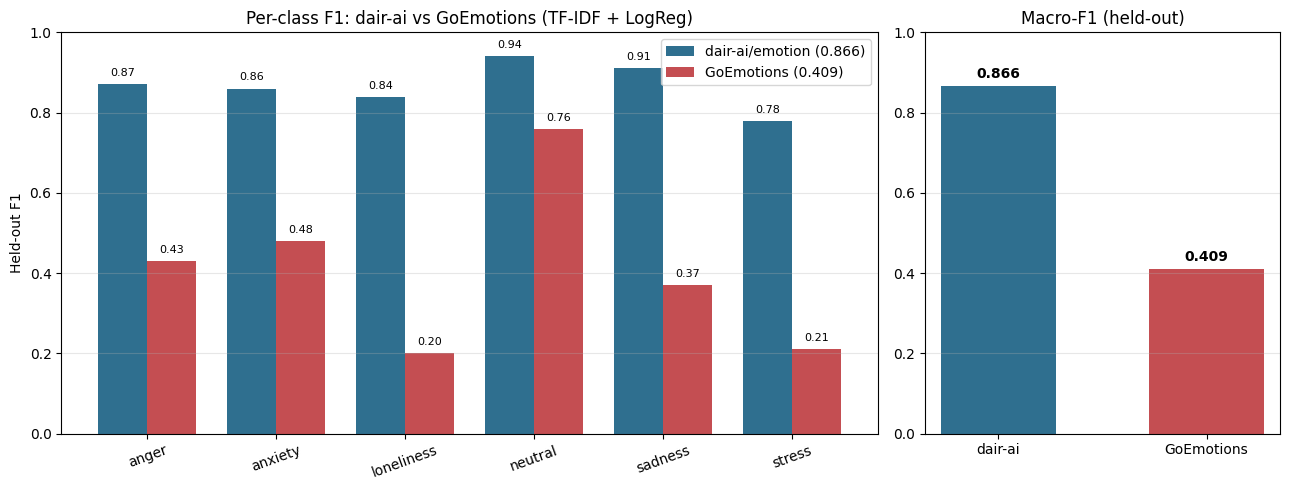

In [5]:
# Reproduce the comparison figure (same as reports/dataset_comparison.png)
x = np.arange(len(TONES)); w = 0.38
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.3, 1]})

axL.bar(x - w/2, f1["dair-ai"],    w, label=f"dair-ai/emotion ({MACRO['dair-ai']})", color="#2f6f8f")
axL.bar(x + w/2, f1["GoEmotions"], w, label=f"GoEmotions ({MACRO['GoEmotions']})", color="#c44e52")
axL.set_xticks(x); axL.set_xticklabels(TONES, rotation=20)
axL.set_ylim(0, 1); axL.set_ylabel("Held-out F1"); axL.legend(); axL.grid(axis="y", alpha=.3)
axL.set_title("Per-class F1: dair-ai vs GoEmotions (TF-IDF + LogReg)")
for i, t in enumerate(TONES):
    axL.text(i - w/2, f1['dair-ai'][t] + .02, f"{f1['dair-ai'][t]:.2f}", ha="center", fontsize=8)
    axL.text(i + w/2, f1['GoEmotions'][t] + .02, f"{f1['GoEmotions'][t]:.2f}", ha="center", fontsize=8)

axR.bar(list(MACRO), list(MACRO.values()), color=["#2f6f8f", "#c44e52"], width=.55)
axR.set_ylim(0, 1); axR.set_title("Macro-F1 (held-out)"); axR.grid(axis="y", alpha=.3)
for i, v in enumerate(MACRO.values()):
    axR.text(i, v + .02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 3. Why did GoEmotions underperform?

Every tone dropped — a dataset-level mismatch, not one bad class. Four reasons:

1. **Noisy, context-dependent text.** GoEmotions is raw Reddit comments: sarcasm,
   slang, and meaning that lives in the surrounding thread. dair-ai/emotion is
   cleaner, self-contained sentences with explicit emotion words. TF–IDF matches
   *words, not meaning*, so it thrives on the clean data and struggles on Reddit.
2. **Oversized `neutral` grab-bag.** Collapsing all 18 positive/ambiguous emotions
   into `neutral` made it ~80% of the GoEmotions test set (3,671 / 4,590). The model
   must separate mild negatives from a huge, internally diverse blob.
3. **`class_weight="balanced"` backfires.** With neutral dominating, balancing makes
   the model over-predict rare negatives — note GoEmotions recall stays high while
   precision collapses (0.12–0.35).
4. **Derived classes evaporate.** GoEmotions test had loneliness n=6, stress n=11 —
   too few to be meaningful.

### Test-set support makes point 2 vivid

In [6]:
support = pd.DataFrame({
    "dair-ai test":    {"anger":275, "anxiety":202, "loneliness":30, "neutral":907,  "sadness":551, "stress":35},
    "GoEmotions test": {"anger":596, "anxiety":76,  "loneliness":6,  "neutral":3671, "sadness":230, "stress":11},
}).reindex(TONES)
support["GoEmotions %"] = (support["GoEmotions test"] / support["GoEmotions test"].sum() * 100).round(1)
support

,dair-ai test,GoEmotions test,GoEmotions %
anger,275,596,13.0
anxiety,202,76,1.7
loneliness,30,6,0.1
neutral,907,3671,80.0
sadness,551,230,5.0
stress,35,11,0.2


## 4. Conclusion & takeaway

- **Bigger/richer ≠ better.** For a bag-of-words model, *dataset fit and cleanliness*
  matter more than raw size. We keep **dair-ai/emotion** (macro-F1 0.866).
- **The right next step for GoEmotions is a better model, not a worse dataset.**
  Its noisy, contextual text is exactly what **Sentence-Transformer embeddings**
  (which understand context and sarcasm) handle well — a clean motivation for the
  v2 upgrade.
- The GoEmotions downloader is preserved at `src/download_goemotions.py`; both
  downloaders share `src/dataset_utils.py`.

### Reproduce this experiment
```bash
# dair-ai baseline
python -m src.download_data --max-per-class 2500
python -m src.download_data --split test
python -m src.train --model logreg && python -m src.evaluate

# GoEmotions swap
python -m src.download_goemotions --max-per-class 2500
python -m src.download_goemotions --split test
python -m src.train --model logreg && python -m src.evaluate
```

## 5. Follow-up: fixing the label scheme (acting on the diagnosis)

If the oversized `neutral` grab-bag was the real bottleneck, fixing it should help.
I changed the GoEmotions remap to map only **true neutral** (id 27) and **drop** the
18 positive emotions rather than mislabel them as neutral.

**Result: held-out macro-F1 rose 0.409 → 0.493 (+0.08)**, with precision up across
the board (anger 0.32→0.48, sadness 0.27→0.45). This confirms the bottleneck was the
**labels, not the features**. It still trails dair-ai (remaining gap = noisy Reddit
text + data-starved stress/loneliness), but it is a real, measured win.

![GoEmotions label-scheme fix](../reports/goemotions_fix.png)

Strict mapping is now the loader default; pass `--lenient-neutral` to reproduce the
original broken scheme.